In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Read the data

In [2]:
f_data = './data.csv'
df = pd.read_csv(f_data, index_col=1)
df.index = pd.to_datetime(df.index, format='%m/%d/%y')
df.head()

,timestep,J,Cl mg/l,Q,ET,Q Cl mg/l,S_scale
datetime,,,,,,,
1983-05-03,0,0.25,1.643836,3.404765,3.279204,NaN,4675.943543
1983-05-04,1,0.00,0.000000,3.032749,2.572585,NaN,4909.717786
1983-05-05,2,6.25,1.643836,2.954061,0.882162,NaN,4979.097380
1983-05-06,3,11.75,1.643836,3.821581,1.653902,NaN,4471.583891
1983-05-07,4,11.25,1.643836,5.064662,0.994315,NaN,3957.744963


# Check zero flow and concentrations

In [3]:
df_new = df.copy()
zero_q = df_new['Q']==0

print(zero_q.sum())


0


# Calculate the relative storage
Using the function reported in Harman (2015)

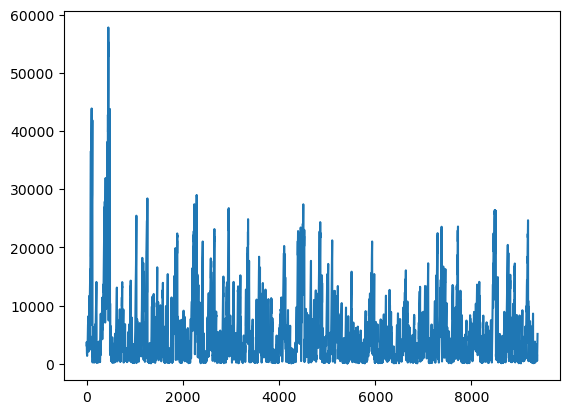

In [ ]:
Q = df['Q'].values # Unit: mm/d

# Convert Q to mm/hr
Q_hr = Q / 24 # mm/hr

# Calculate the sensitivity
g = np.exp(-2.54 + 1.2 * np.log(Q_hr) + 0.000537 * (np.log(Q_hr)) ** 2)

# Integration to mm/d
dS = 1. / g * 24

plt.plot(dS)

In [13]:
df['dS-PJ'] = dS

# Save the files

In [14]:
df.to_csv('./data-PJ.csv')